# I. Chargement des données 

In [ ]:
# ======================================================
# Chargement des datasets et création des X / Y
# ======================================================

import pandas as pd
from pathlib import Path

data_dir = Path("../data/processed")

# ---------------------------
# Chargement TRAIN
# ---------------------------
train_full = pd.read_csv(data_dir / "train_full.csv")
train_reduced = pd.read_csv(data_dir / "train_reduced.csv")
train_full_norm = pd.read_csv(data_dir / "train_full_norm.csv")
train_reduced_norm = pd.read_csv(data_dir / "train_reduced_norm.csv")

train_with_date = pd.read_csv(
    data_dir / "train_full_with_date.csv",
    parse_dates=["date"]
)

# ---------------------------
# Chargement PREDICTION PERIOD
# ---------------------------
prediction_full = pd.read_csv(data_dir / "prediction_full.csv")
prediction_reduced = pd.read_csv(data_dir / "prediction_reduced.csv")
prediction_full_norm = pd.read_csv(data_dir / "prediction_full_norm.csv")
prediction_reduced_norm = pd.read_csv(data_dir / "prediction_reduced_norm.csv")

# ======================================================
# DATAFRAMES - TRAIN
# ======================================================

y = train_full["mean"]

X = train_full.drop(columns="mean")
XR = train_reduced.drop(columns="mean")
XN = train_full_norm.drop(columns="mean")
XRN = train_reduced_norm.drop(columns="mean")

# ======================================================
# DATAFRAMES - PREDICTION
# ======================================================

X_pred = prediction_full.drop(columns="mean")
X_pred_R = prediction_reduced.drop(columns="mean")
X_pred_N = prediction_full_norm.drop(columns="mean")
X_pred_RN = prediction_reduced_norm.drop(columns="mean")

print("Datasets chargés et X / y initialisés.")

Datasets chargés et X / y initialisés.


In [2]:
# ======================================================
# Initialisation des modèles et des métriques
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# ------------------------------------------------------
# Tableau de suivi des performances
# ------------------------------------------------------
metrics = pd.DataFrame(columns=[
    "Model",
    "Dataset utilisé",
    "Split",
    "Remarques",
    "R2",
    "MAPE"
])

print("Environnement de modélisation initialisé.")

Environnement de modélisation initialisé.


ValueError: x and y must have same first dimension, but have shapes (816,) and (24864,)

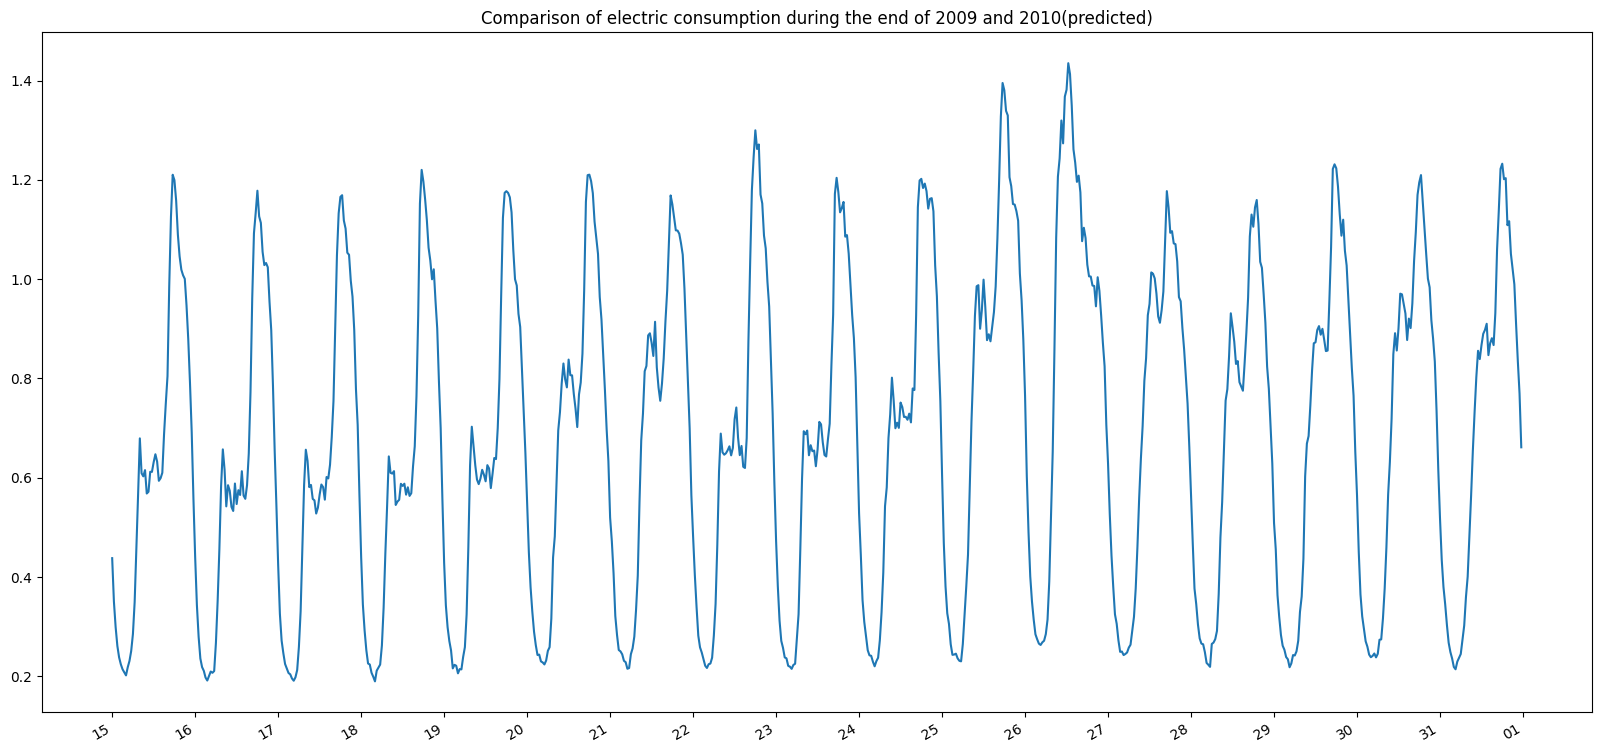

In [9]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit

x = XR
y = train_reduced["mean"]

# Diviser les données en ensembles d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(XR, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)

date_rng = pd.date_range(start='2010-12-15', end='2010-12-31 23:59:59', freq='30min')

fig, ax1 = plt.subplots(nrows=1, ncols=1,figsize=(20,10))
plt.gcf().autofmt_xdate()
plt.title("Comparison of electric consumption during the end of 2009 and 2010(predicted)")
ax1.plot(date_rng, Y_dec09, label = 'Data 2009')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax1.plot(date_rng, y, linewidth = 2, label = 'Prediction 2010 - Multiple Linear Regression')
ax1.legend(loc='upper left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Electric consumption (kWh)')
plt.show()